# Federal University of Bahia (UFBA)  
## Graduate Program in Geophysics (PPGEOF)  
### Research Group: LIGA - Laboratory of Innovation in Applied Geophysics  

---

**Notebook Title:** *FWI Conventional*  
**Author:** *Msc Student. Rômulo Barbosa*  
**Advisor:** *Prof.Dr. Peterson Nogueira Santos*  

**Course:** *Master Degree*

**Line of Research:** *Seismic Imaging*  

**Institution:** *Institute of Geosciences – IGEO/UFBA*  
**Date:** *05/10/2025*  

---

### Objectives  
- This tutorial shows an implementation of FWI by using Pylops.

---

### Description  

This notebook contains:  

- **Brief summary of what will be done:**  
  - FWI using the PyLops library.

- **Data or models used:**  
  - Marmousi true velocity model loaded from binary file (`model-t.bin`)
  - Marmousi inicial velocity model loaded from binary file (`model-inicial.bin`)  

- **Applied methodology:**  
  - Seismic data were generated using the true velocity model with a 2D acoustic wave equation operator (`AcousticWave2D`) from Pylops
  - Objective function applied were L2 Norm
e function applied were L2 Norm

# Importing Libraries

In [1]:
import copy
import numpy as np
from copy import deepcopy
from pylops.utils import *
from FWI import FWI_Multiscale
import matplotlib.pyplot as plt
from devito import configuration
from scipy.ndimage import gaussian_filter
from pylops.waveeqprocessing.twoway import ViscoAcousticWave2D
from utils import (plot_data, get_alfa_g)
# from utils import (plot_data, Frequency_spectrum, plot_freq_spectrum, create_mask_value, get_alfa_g)

configuration['log-level'] = 'ERROR'

In [2]:
from sympy.utilities.exceptions import SymPyDeprecationWarning
import warnings

warnings.filterwarnings("ignore", category=SymPyDeprecationWarning)


## Initializing Model Parameters

The foundation of **Pylops** functionality lies in the use of operators, in this case, the 2D acoustic operator (**AcousticWave2D**). This operator wraps **DEVITO** objects, such as SeismicModel, which includes the velocity model, time step (dt), and other details and Geometry, which contains all the necessary geometry information, such as receiver and source coordinates.

By encapsulating these objects, users only need to focus on the parameters to be applied, rather than on how the underlying objects are built.

Below are the parameters required for creating the **AcousticWave2D** operator.

In [3]:
# Modelling parameters (in meters, seconds and Hz)
par = {
    'nx': 98,   'dx': 25,     'ox': 0.,
    'nz': 100,  'dz': 25,     'oz': 0.,
    'ns': 20,   'ds': 175,    'sz': 0.,
    'nr': 98,   'dr': 25,     'rz': 0.,
    'nt': 3000, 'dt': 0.002,   't0': 0.,
    'nw': 5,   'freq': 20}

shape = (par['nx'], par['nz'])
spacing = (par['dx'], par['dz'])
origin = (par['ox'], par['oz'])
src_type = 'Ricker' # or 'Ricker_Devito' if you want to use Devito Source
dtype = np.float32
space_order = 8
nbl = 50
witer = 10 # wolfe iterations

In [4]:
# Setting model velocity path
path_true_model="Petrophysics/vp_rho_smeaheia.npz"

# Loading model velocity
vp = np.load(path_true_model)['vp']
rho = np.load(path_true_model)['rho']
vp0 = gaussian_filter(vp, sigma = (5,5))
rho0 = gaussian_filter(rho, sigma = (5,5))
b = 1./rho
b_init = 1./rho0

# Applying water layer
# msk = create_mask_value(vp, 1.52)
vp_min = np.min(vp)
vp_max = np.max(vp)
rho_min = np.min(rho)
rho_max = np.max(rho)
b_min = np.min(b)
b_max = np.max(b)

# Setting receivers positions
x_r = np.zeros((par['nr'], 2))
x_r[:, 0] = np.arange(par['nr']) * par['dr'] # receivers positions
x_r[:, 1] = par['rz']

# Setting source positions
model_domain_size = ((shape[0]-1)*spacing[0], (shape[1]-1)*spacing[1])
x_s = np.zeros((par['ns'], 2))
x_s[:,0] = np.linspace(0., model_domain_size[0], num=par['ns'])
x_s[:,1] = origin[1] + spacing[1] * 2

# Setting propagation time
tn = (np.arange(par['nt'])*par['dt'])[-1]

# Creating modelling operator
Dop = ViscoAcousticWave2D(shape=shape,origin=origin, spacing=spacing, vp=vp*1e3, b=b, qp=1, nbl=nbl, 
                          space_order=space_order,src_x=x_s[:,0], src_z=x_s[:,1], rec_x=x_r[:,0],
                          rec_z=x_r[:,1], t0=par['t0'], tn=par['nt'], src_type=src_type, f0=par['freq'],
                          dtype=dtype,op_name="fwd", dt=par['dt']*1e3, kernel='maxwell', time_order=1)

vp_true = deepcopy(vp)
vp_init = deepcopy(vp0) 
rho_true = deepcopy(rho)
rho_init = deepcopy(rho0)

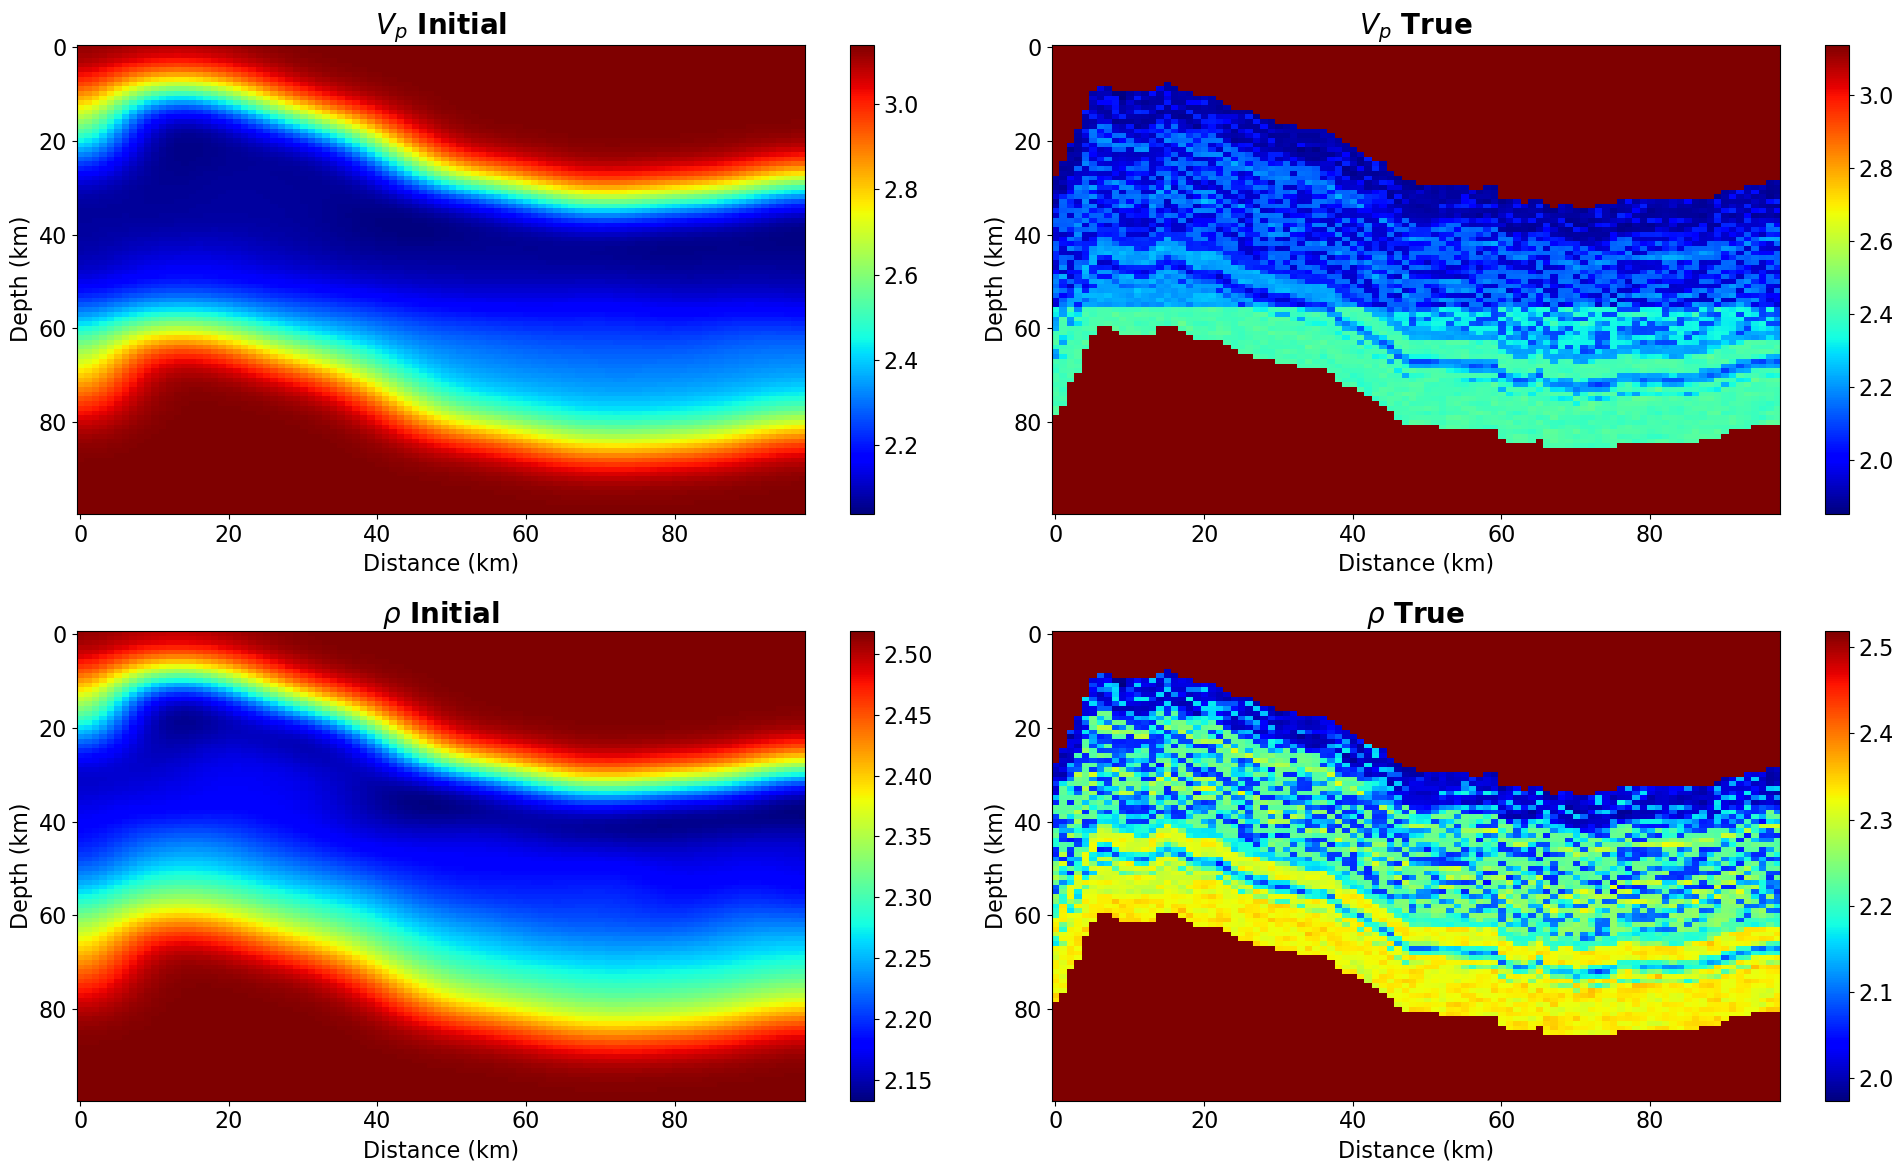

In [5]:
# Plotting velocity models
plt.figure(figsize=(20,12))
plt.subplot(2,2,1)
plt.imshow(vp_init.T,aspect='auto',cmap='jet')
plt.ylabel('Depth (km)', fontsize=16)
plt.xlabel('Distance (km)',fontsize=16)
plt.title(r'${V_p}$ Initial', fontsize=20, fontweight='bold')
plt.colorbar()

plt.subplot(2,2,2)
plt.imshow(vp_true.T,aspect='auto',cmap='jet')
plt.ylabel('Depth (km)', fontsize=16)
plt.xlabel('Distance (km)',fontsize=16)
plt.title('${V_p}$ True', fontsize=20, fontweight='bold')
plt.colorbar()

plt.subplot(2,2,3)
plt.imshow(rho_init.T,aspect='auto',cmap='jet')
plt.ylabel('Depth (km)', fontsize=16)
plt.xlabel('Distance (km)',fontsize=16)
plt.title(r'${\rho}$ Initial', fontsize=20, fontweight='bold')
plt.colorbar()

plt.subplot(2,2,4)
plt.imshow(rho_true.T,aspect='auto',cmap='jet')
plt.ylabel('Depth (km)', fontsize=16)
plt.xlabel('Distance (km)',fontsize=16)
plt.title(r'${\rho}$ True', fontsize=20, fontweight='bold')
plt.colorbar()
plt.tight_layout()

##  Generating Observed Data (Dobs)

Pylops performs forward propagation as follows:

$dobs = Dop * vptrue$, 

where $m$ represents the velocity value $vp$ em m/s.

In [6]:
dobs = Dop * np.stack([vp_true, 1./rho_true])

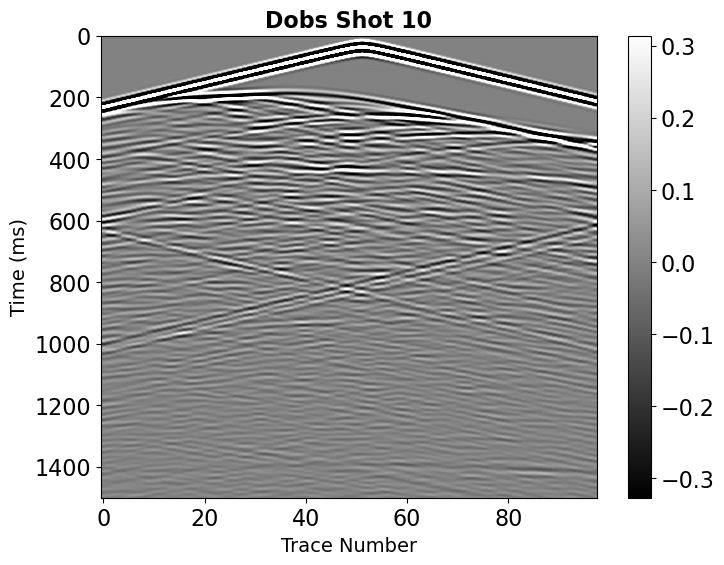

In [7]:
# Plotting Observed Data
shot_dobs = int(par['ns']/2)
plot_data(dobs,shot=shot_dobs, title=f'Dobs Shot {shot_dobs}')

# Conventional FWI

**Full-Waveform Inversion** is a geophysical technique used to refine subsurface models by inverting seismic data. 

To run FWI Conventional, you may set some parameters as:

- **iterations**: Number of iterations for each frequency.
- **vp_min**: Minimum value for the velocity model.
- **vp_max**: Maximum value for the velocity model.
- **water_layer**: Number of layers near the water region that should not be updated during inversion

In [8]:
def get_alfa_conv(grad1=None, grad2=None):
    g1 = grad1.reshape(-1)
    g2 = grad2.reshape(-1)
    g = np.concatenate((g1, g2)).astype(np.float32)
    alfa = .5/np.max(g)
    return alfa

# def get_alfa_g(yk1=None, yk2=None, sk1=None, sk2=None):
#     m1 = sk1.reshape(-1)
#     m2 = sk2.reshape(-1)

#     m = np.concatenate((m1, m2)).astype(np.float32)
        
#     term1 = np.dot(m, m)   
    
#     g1 = yk1.reshape(-1)
#     g2 = yk2.reshape(-1)
    
#     g = np.concatenate((g1, g2)).astype(np.float32)

#     term2 = np.dot(m, g)
#     term3 = np.dot(g, g)
    
#     abb1 = term1 / term2
#     abb2 = term2 / term3
#     abb3 = abb2 / abb1
        
#     if abb3 > 0 and abb3 < 1:
#         alfa = abb2
#     else:
#         alfa = abb1
        
#     return alfa

def plot_model(vp0, vp, vp_init, rho0, rho, rho_init):
    plt.figure(figsize=(18,8)) #24,10
    plt.subplot(2,3,1)
    plt.imshow(vp0.T,aspect='auto',cmap='jet')
    plt.ylabel('Depth (km)', fontsize=16)
    plt.xlabel('Distance (km)',fontsize=16)
    plt.title('Initial Model', fontsize=20, fontweight='bold')
    plt.colorbar()
    
    plt.subplot(2,3,2)
    plt.imshow(vp.T,aspect='auto',cmap='jet')
    plt.ylabel('Depth (km)', fontsize=16)
    plt.xlabel('Distance (km)',fontsize=16)
    plt.title('True Model', fontsize=20, fontweight='bold')
    plt.colorbar()
    
    plt.subplot(2,3,3)
    plt.imshow(vp_init.T,aspect='auto',cmap='jet')
    plt.ylabel('Depth (km)', fontsize=16)
    plt.xlabel('Distance (km)',fontsize=16)
    plt.title('Inverted Model', fontsize=20, fontweight='bold')
    plt.colorbar()
    
    plt.subplot(2,3,4)
    plt.imshow(rho0.T,aspect='auto',cmap='jet')
    plt.ylabel('Depth (km)', fontsize=16)
    plt.xlabel('Distance (km)',fontsize=16)
    plt.title('Initial Model', fontsize=20, fontweight='bold')
    plt.colorbar()
    
    plt.subplot(2,3,5)
    plt.imshow(rho.T,aspect='auto',cmap='jet')
    plt.ylabel('Depth (km)', fontsize=16)
    plt.xlabel('Distance (km)',fontsize=16)
    plt.title('True Model', fontsize=20, fontweight='bold')
    plt.colorbar()
    
    plt.subplot(2,3,6)
    plt.imshow(rho_init.T,aspect='auto',cmap='jet')
    plt.ylabel('Depth (km)', fontsize=16)
    plt.xlabel('Distance (km)',fontsize=16)
    plt.title('Inverted Model', fontsize=20, fontweight='bold')
    plt.colorbar()
    plt.tight_layout()
    plt.show()

def plot_datas(dobs,dcalc,res, grads_vp, grads_rho):
    # vmax = np.percentile(dobs, 99)
    # vmax_dcalc = np.percentile(dcalc, 99)
    plt.figure(figsize=(15,4))
    plt.subplot(1,3,1)
    plt.imshow(dobs[int(par['ns']/2)].T, aspect='auto',cmap='gray',) #vmin=-vmax, vmax=vmax)
    plt.title('Dobs', fontsize=14)
    plt.colorbar()
    plt.subplot(1,3,2)
    plt.imshow(dcalc[int(par['ns']/2)].T, aspect='auto',cmap='gray',) #vmin=-vmax_dcalc, vmax=vmax_dcalc
    plt.title('Dcalc', fontsize=14)
    plt.colorbar()
    plt.subplot(1,3,3)
    plt.imshow(res[int(par['ns']/2)].T, aspect='auto',cmap='seismic')
    plt.title('Res', fontsize=14)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.imshow(grads_vp.T, aspect='auto',cmap='seismic')
    plt.title(r'$\nabla{V_p}$', fontsize=14)
    plt.colorbar()
    plt.subplot(1,2,2)
    plt.imshow(grads_rho.T, aspect='auto',cmap='seismic')
    plt.title(r'$\nabla \rho$', fontsize=14)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

def normalize(arr):
    return (arr - arr.min()) / (arr.max() - arr.min())

In [9]:
# from numpy.linalg import norm
# iterations = 150; witer=5
# water_layer = par['nw']

# history = np.zeros((iterations, 1)) # objective function

# for iter in range(iterations):
#     print("Iteration ", iter + 1)

#     # generating calculated data
#     dcalc = Dop * np.stack([vp_init, 1./rho_init])

#     # calculating adjoint source
#     res = dcalc - dobs

#     # calculating objective function
#     FO = .5*norm(res)**2
#     print("FO: ", FO)
#     print('')

#     # calculating gradient
#     grads_vp, grads_rho = Dop.H*res
    
#     # objective function storage
#     history[iter] = FO
    
#     grads_vp[:,0:par['nw']] = 0.
#     grads_rho[:,0:par['nw']] = 0.
    
#     if iter == 0 or iter==range(iterations)[-1]:
#         plot_datas(dobs, dcalc, res, grads_vp, grads_rho)        
#     else:
#         pass

#     if iter == 0:
#         # alfa = get_alfa_conv(grads_vp, grads_rho)
#         alfa_vp = .05 / np.max(grads_vp)
#         alfa_rho = .05 / np.max(grads_rho)
#     else:
#         ykvp, skvp = grads_vp - gradp_vp, vp_init - pvp ; alfa_vp = get_alfa_g(ykvp, skvp)
#         ykrho, skrho = grads_rho - gradp_rho, rho_init - prho ; alfa_rho = get_alfa_g(ykrho, skrho)
    
#         print(f'Alfa Vp: {alfa_vp}')
#         print(f'Alfa rho: {alfa_rho}')
#         # alfa = get_alfa_g(ykvp, ykrho, skvp, skrho)

#     # if iter == 0:
#     #     alfa_vp = .05 / np.max(grads_vp)
#     #     alfa_rho = .05 / np.max(grads_rho)
#     # else:
#     #     ykvp, skvp = grads_vp - gradp_vp, vp_init - pvp
#     #     ykrho, skrho = grads_rho - gradp_rho, rho_init - prho

#     #     alfa_vp = get_alfa_g(ykvp, skvp)
#     #     alfa_rho = get_alfa_g(ykrho, skrho)

#     gradp_vp = deepcopy(grads_vp)
#     pvp = deepcopy(vp_init)

#     gradp_rho = deepcopy(grads_rho)
#     prho = deepcopy(rho_init)
   
#     # # update model
#     # if iter == 0:
#     #     vp_init = vp_init - alfa * grads_vp  #alfa_vp
#     #     rho_init = rho_init - alfa * grads_rho #alfa_rho
#     # else:
#     #     vp_init = vp_init - alfa_vp * grads_vp  #alfa_vp
#     #     rho_init = rho_init - alfa_rho * grads_rho #alfa_rho

#     vp_init = vp_init - alfa_vp * grads_vp  #alfa_vp
#     rho_init = rho_init - alfa_rho * grads_rho #alfa_rho  
#     vp_init[: ,0:par['nw']] = vp[:, 0:par['nw']]
#     rho_init[: ,0:par['nw']] = rho[:, 0:par['nw']]

#     np.putmask(vp_init, vp_init > vp_max, vp_max)
#     np.putmask(vp_init, vp_init < vp_min, vp_min)
#     np.putmask(rho_init, rho_init > rho_max, rho_max)
#     np.putmask(rho_init, rho_init < rho_min, rho_min)
#     if iter in range(0,150,25):
#         plot_model(vp0, vp, vp_init, rho0, rho, rho_init)
#         print('')
#         print('='*200)
#     else:
#         pass
#     # if iter > 0 and (history[iter] > history[iter-1]):
#     #     print(f'Wolfe Condition must be applied, FO = {history[iter]}')
#     #     for w in range(witer):
#     #         print(f"Global iteration {iter + 1}, LS iteration {w + 1}")
#     #         alfa_vp = .5 * alfa_vp
#     #         alfa_rho = .5 * alfa_rho
#     #         vp_init, rho_init = pvp, prho

#     #         vp_init = vp_init = vp_init - alfa_vp * grads_vp
#     #         rho_init = rho_init - alfa_rho * grads_rho

#     #         if water_layer > 0:
#     #             nbl = Dop.model.nbl
                
#     #             vp0 = Dop.model.vp.data[nbl:-nbl, nbl:-nbl] #tirando a borda
#     #             b0 = Dop.model.b.data[nbl:-nbl, nbl:-nbl]
#     #             rho0 = 1./b0

#     #             vp_init[:,0:water_layer] = vp0[:,0:water_layer] 
#     #             rho_init[:,0:water_layer] = rho0[:,0:water_layer] 

#     #         params_wolfe = np.stack([vp_init, rho_init])  
            
#     #         dcalc_wolfe = Dop * params_wolfe
#     #         res_wolfe = dcalc_wolfe - dobs
#     #         FO_wolfe = 0.5 * norm(res_wolfe)**2
#     #         print("FO Wolfe: ", FO_wolfe)
#     #         print('')

#     #         if FO_wolfe < history[iter-1]:
#     #             print('Get out from line search - Wolfe conditions met')
#     #             history[iter] = FO_wolfe
#     #             break
                
#     #         elif w == witer-1:
#     #             ykvp, skvp = grads_vp - gradp_vp, vp_init - pvp
#     #             ykrho, skrho = grads_rho - gradp_rho, rho_init - prho
        
#     #             alfa_vp = get_alfa_g(ykvp, skvp)
#     #             alfa_rho = get_alfa_g(ykrho, skrho)

#     #             vp_init = vp_init - alfa_vp * grads_vp
#     #             rho_init = rho_init - alfa_rho * grads_rho

#     #             params_wolfe = np.stack([vp_init, rho_init])  
                
#     #             dcalc_wolfe = Dop * params_wolfe
#     #             res_wolfe = dcalc_wolfe - dobs
#     #             print(res_wolfe)
#     #             FO_wolfe = 0.5 * norm(res_wolfe)**2
#     #             print("FO Wolfe: ", FO_wolfe)
#     #             print('')

#     #             if FO_wolfe < history[iter-1]:
#     #                 history[iter] = FO_wolfe
        
# print('Done!')

Iteration  1
FO:  946.4957447781053



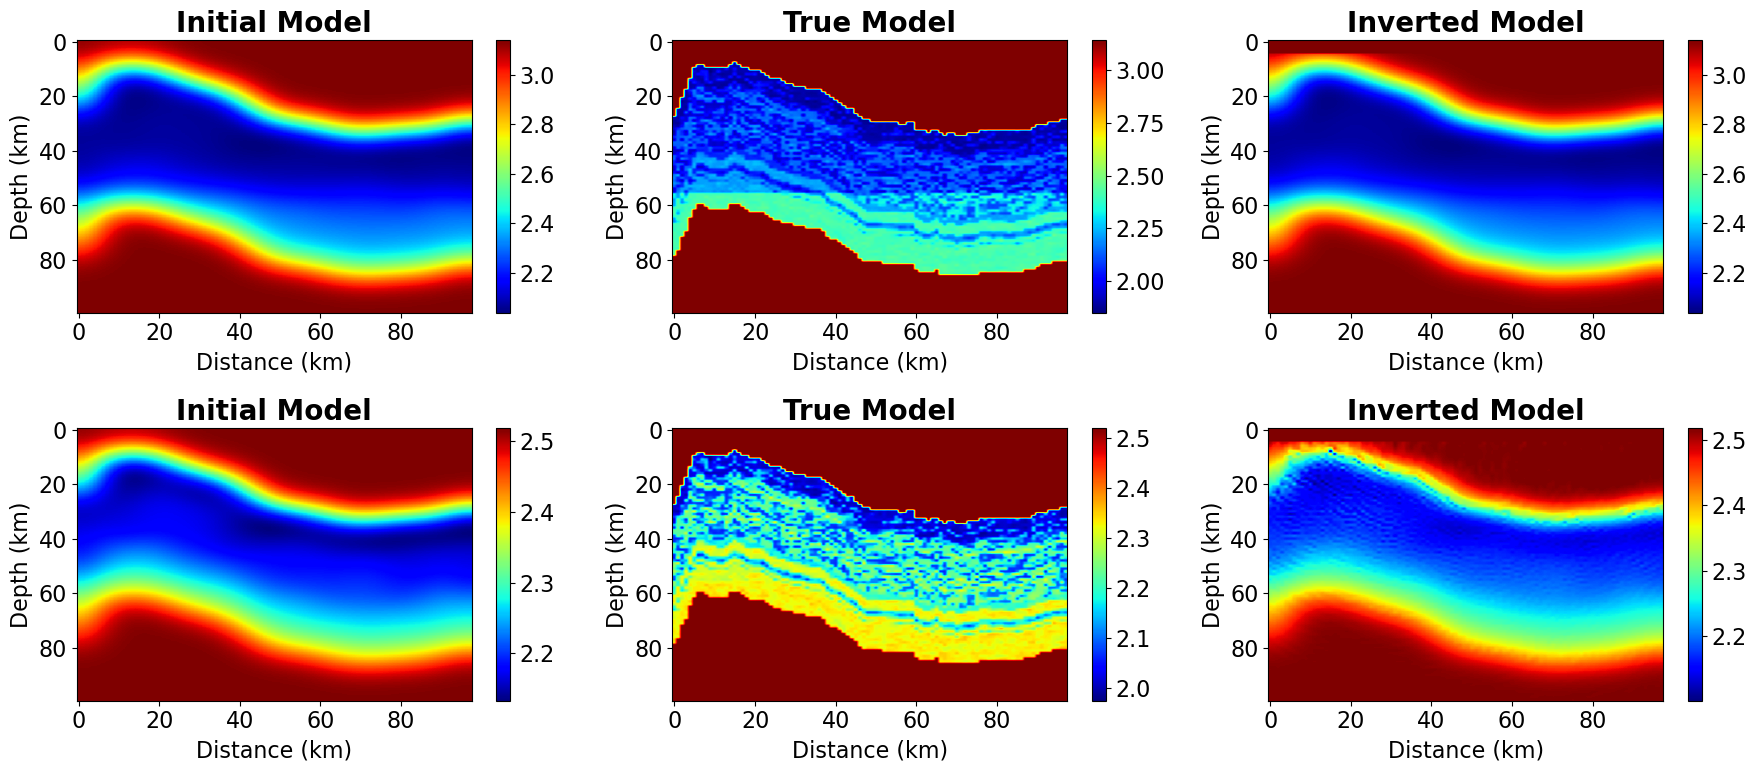


Iteration  2
FO:  617.3238564792046

Iteration  3
FO:  436.16176968120453

Iteration  4
FO:  326.87503598341027

Iteration  5
FO:  277.71265426971513

Iteration  6
FO:  250.2233172458382

Iteration  7
FO:  231.12655830645963

Iteration  8
FO:  212.20562661296754

Iteration  9
FO:  194.9844288320037

Iteration  10
FO:  181.7483228439978

Iteration  11
FO:  171.95876151742414

Iteration  12
FO:  163.77625049863127

Iteration  13
FO:  155.96157895820215

Iteration  14
FO:  148.06587350103837

Iteration  15
FO:  140.31182598766645

Iteration  16
FO:  133.41463319158538

Iteration  17
FO:  127.72047442866507

Iteration  18
FO:  122.87860360070954

Iteration  19
FO:  118.36967277761187

Iteration  20
FO:  113.91255901068189

Iteration  21
FO:  109.51657305537265

Iteration  22
FO:  105.41517895202742

Iteration  23
FO:  101.79079170231307

Iteration  24
FO:  98.59623149641675

Iteration  25
FO:  95.63979069231254

Iteration  26
FO:  92.75540676294622

Iteration  27
FO:  89.88765386475279

I

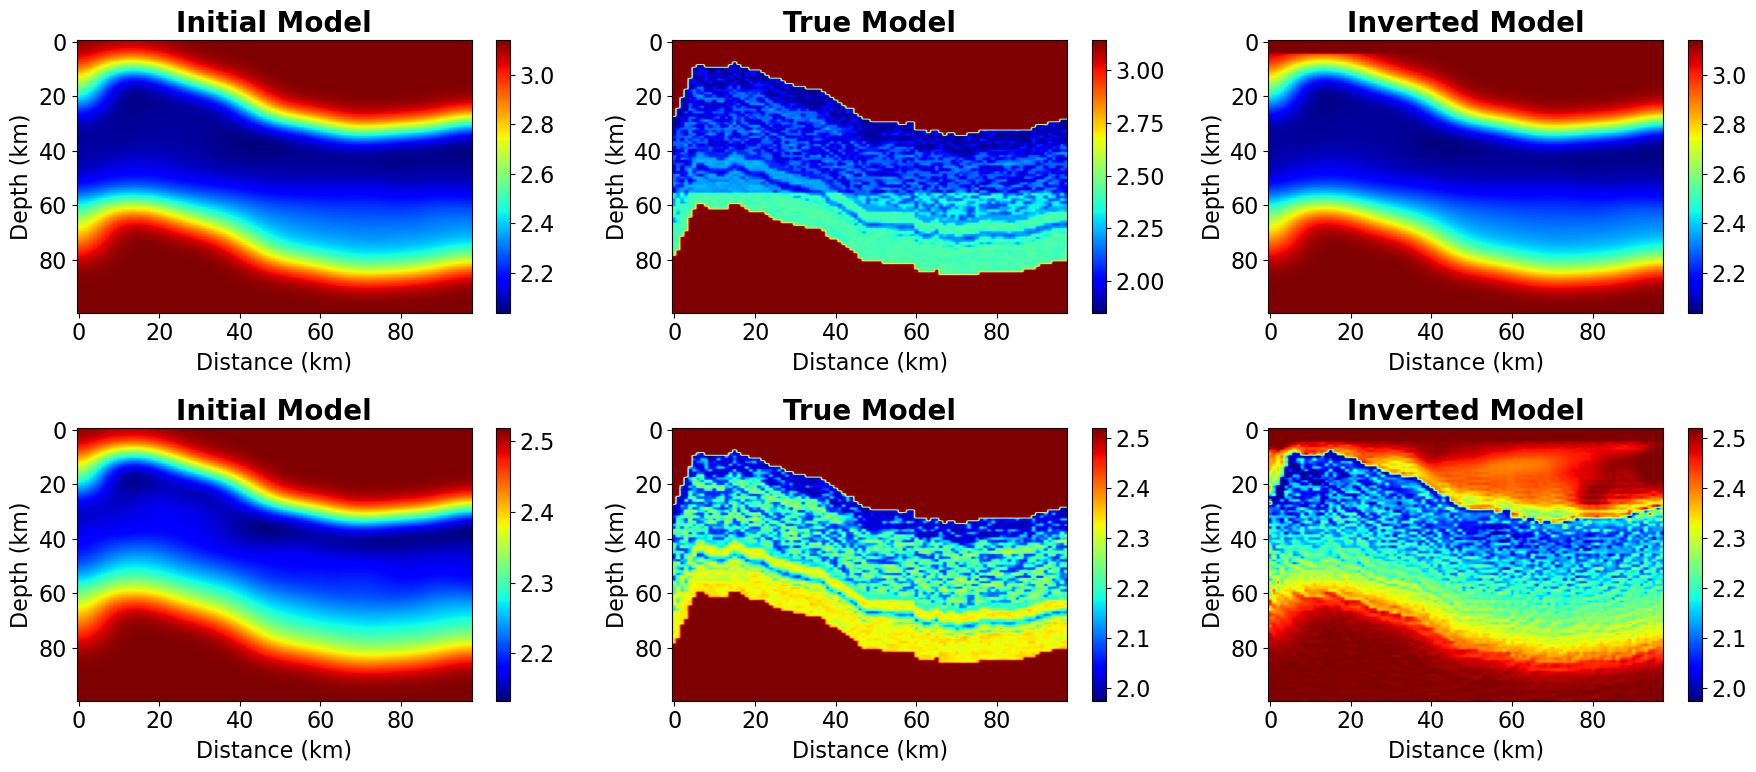


Iteration  101
FO:  28.680219899049916

Iteration  102
FO:  28.42895292365131

Iteration  103
FO:  28.187709200122413

Iteration  104
FO:  27.948363282034848

Iteration  105
FO:  27.707929321637607

Iteration  106
FO:  27.47041431277114

Iteration  107
FO:  27.239411872296955

Iteration  108
FO:  27.012921092129545

Iteration  109
FO:  26.790991830085773

Iteration  110
FO:  26.57476465883076

Iteration  111
FO:  26.361722941890548

Iteration  112
FO:  26.147431682697515

Iteration  113
FO:  25.934176361048344

Iteration  114
FO:  25.728645114102733

Iteration  115
FO:  25.531004745536052

Iteration  116
FO:  25.334974974457623

Iteration  117
FO:  25.137746405312214

Iteration  118
FO:  24.942662610547018

Iteration  119
FO:  24.75240821014495

Iteration  120
FO:  24.565428966571858

Iteration  121
FO:  24.38161594215171

Iteration  122
FO:  24.201993035160285

Iteration  123
FO:  24.025225634732237

Iteration  124
FO:  23.847538594280195

Iteration  125
FO:  23.670077995812903

Iter

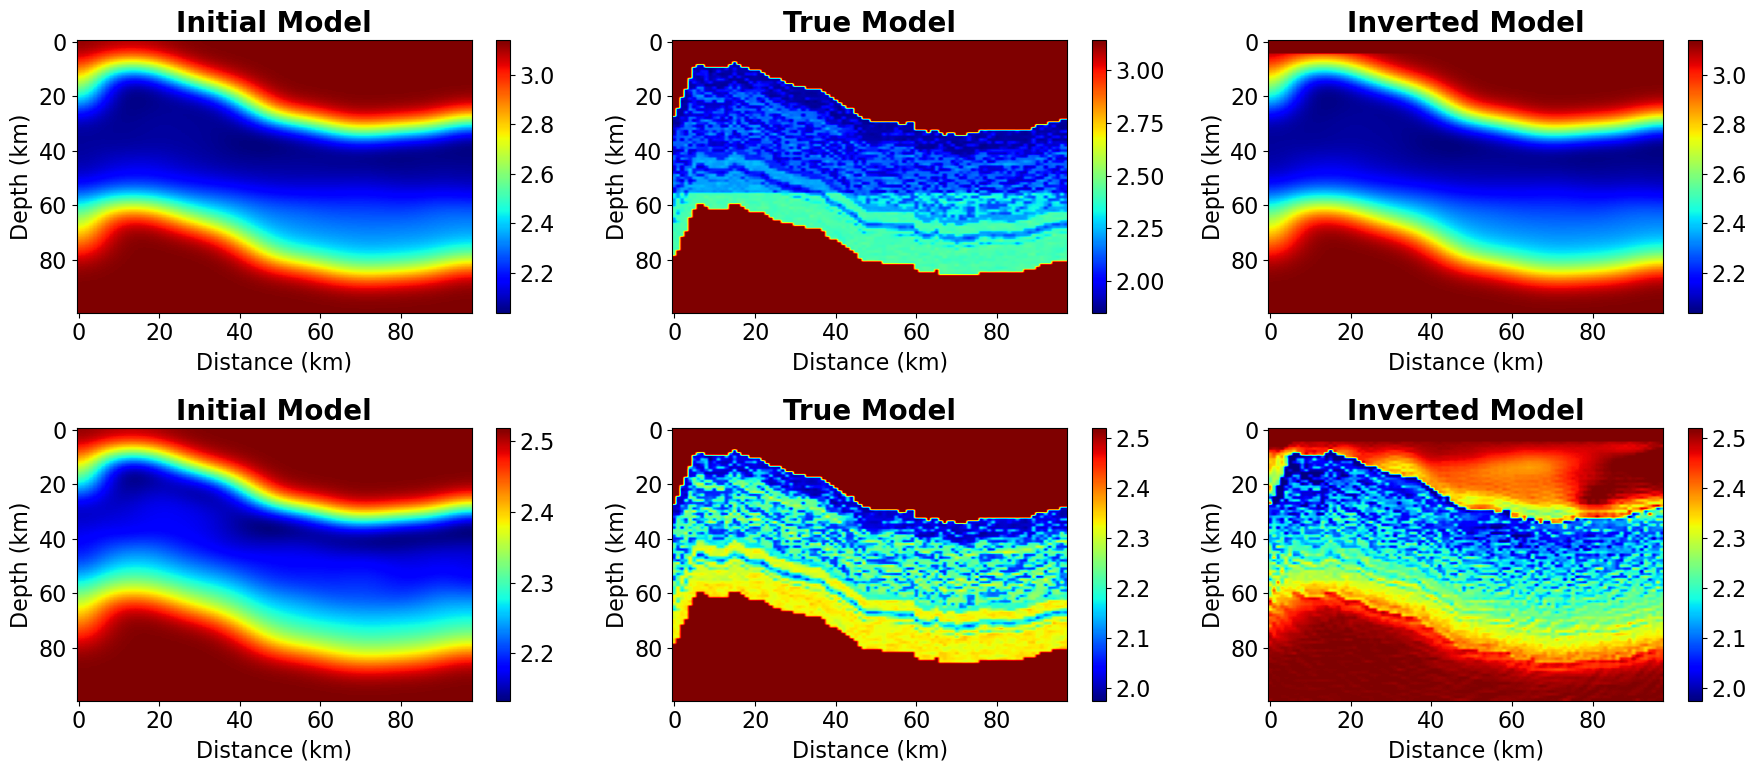


Iteration  200
FO:  15.23324690860693

Iteration  201
FO:  15.159622432850028

Iteration  202
FO:  15.086412039382708

Iteration  203
FO:  15.014936185851184

Iteration  204
FO:  14.94420616800926

Iteration  205
FO:  14.873484492109242

Iteration  206
FO:  14.803431303104048

Iteration  207
FO:  14.734977509442729

Iteration  208
FO:  14.66667460656754

Iteration  209
FO:  14.597953235270438

Iteration  210
FO:  14.529940751409526

Iteration  211
FO:  14.463984857187029

Iteration  212
FO:  14.398652385441892

Iteration  213
FO:  14.332811669753937

Iteration  214
FO:  14.267228814337159

Iteration  215
FO:  14.202995868516155

Iteration  216
FO:  14.139526552357438

Iteration  217
FO:  14.076027325128962

Iteration  218
FO:  14.013130434585037

Iteration  219
FO:  13.95164887808687

Iteration  220
FO:  13.890244685740186

Iteration  221
FO:  13.828326424637567

Iteration  222
FO:  13.767091932195513

Iteration  223
FO:  13.707793391808536

Iteration  224
FO:  13.648996535071205

Ite

In [ ]:
from numpy.linalg import norm
iterations = 400 ; witer=5
water_layer = par['nw']

history = np.zeros((iterations, 1)) 
b_init = 1.0 / rho_init

for iter in range(iterations):
    print("Iteration ", iter + 1)

    # b_init = 1.0 / rho_init

    # forward usa b_init
    dcalc = Dop * np.stack([vp_true, b_init])
    
    res = dcalc - dobs
    FO = 0.5 * norm(res)**2
    print("FO: ", FO)
    print('')
    
    grads_vp, grads_b = Dop.H * res 
    history[iter] = FO
    
    grads_vp[:, :water_layer] = 0.0
    grads_b[:,  :water_layer] = 0.0
   
    if iter == 0:
        alfa_vp = 0.05 / np.max(np.abs(grads_vp))
        alfa_b  = 0.05 / np.max(np.abs(grads_b))
    else:
        # ykvp, skvp = grads_vp - gradp_vp, vp_init - pvp
        ykb,  skb  = grads_b  - gradp_b,  b_init  - pb
        # alfa_vp = get_alfa_g(ykvp, skvp)
        alfa_b  = get_alfa_g(ykb,  skb)

    gradp_vp = deepcopy(grads_vp)
    pvp = deepcopy(vp_init)

    gradp_b = deepcopy(grads_b)
    pb = deepcopy(b_init)
    
    # update
    # vp_init = vp_init - alfa_vp * grads_vp
    b_init  = b_init - alfa_b  * grads_b

    # print(f'alfa b: {alfa_b}')
    # plot_datas(dobs, dcalc, res, alfa_vp*grads_vp, alfa_b*grads_b)
    
    rho_init = 1.0 / b_init
 
    vp_init[: ,0:par['nw']] = vp[:, 0:par['nw']]
    b_init[: ,0:par['nw']] = b[:, 0:par['nw']]
    rho_init[: ,0:par['nw']] = rho[:, 0:par['nw']]

    # np.putmask(vp_init, vp_init > vp_max, vp_max)
    # np.putmask(vp_init, vp_init < vp_min, vp_min)
    np.putmask(rho_init, rho_init > rho_max, rho_max)
    np.putmask(rho_init, rho_init < rho_min, rho_min)
    if iter in range(0,200,99):
        plot_model(vp0, vp, vp_init, rho0, rho, rho_init)
        print('')
        print('='*200)
    else:
        pass
        
print('Done!')

## Plotting normalized objective function

In [ ]:
# Plot objective function decrease
plt.figure()
plt.plot(history)
plt.xlabel('Iteration number')
plt.ylabel('Misift value Phi')
# plt.vlines(x=2,ymin=history.min(),ymax=history.max(), color='red')
plt.title('Convergence')

In [ ]:
plt.figure(figsize=(24,10))
plt.subplot(2,3,1)
plt.imshow(vp0.T,aspect='auto',cmap='jet')
plt.ylabel('Depth (km)', fontsize=16)
plt.xlabel('Distance (km)',fontsize=16)
plt.title('Initial Model', fontsize=20, fontweight='bold')
plt.colorbar()

plt.subplot(2,3,2)
plt.imshow(vp.T,aspect='auto',cmap='jet')
plt.ylabel('Depth (km)', fontsize=16)
plt.xlabel('Distance (km)',fontsize=16)
plt.title('True Model', fontsize=20, fontweight='bold')
plt.colorbar()

plt.subplot(2,3,3)
plt.imshow(vp_init.T,aspect='auto',cmap='jet')
plt.ylabel('Depth (km)', fontsize=16)
plt.xlabel('Distance (km)',fontsize=16)
plt.title('Inverted Model', fontsize=20, fontweight='bold')
plt.colorbar()

plt.subplot(2,3,4)
plt.imshow(rho0.T,aspect='auto',cmap='jet')
plt.ylabel('Depth (km)', fontsize=16)
plt.xlabel('Distance (km)',fontsize=16)
plt.title('Initial Model', fontsize=20, fontweight='bold')
plt.colorbar()

plt.subplot(2,3,5)
plt.imshow(rho.T,aspect='auto',cmap='jet')
plt.ylabel('Depth (km)', fontsize=16)
plt.xlabel('Distance (km)',fontsize=16)
plt.title('True Model', fontsize=20, fontweight='bold')
plt.colorbar()

plt.subplot(2,3,6)
plt.imshow(rho_init.T,aspect='auto',cmap='jet')
plt.ylabel('Depth (km)', fontsize=16)
plt.xlabel('Distance (km)',fontsize=16)
plt.title('Inverted Model', fontsize=20, fontweight='bold')
plt.colorbar()
plt.tight_layout()
# plt.savefig('results_equal_fortran.png', format='png')

In [ ]:
# np.savez_compressed('vel_final.npz', arr_0=vp_init)